In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_parquet('CWRU/12k data/0_hp_load/CWRU_raw_data_0_load.parquet')
print(df.head())

    DE_data   fault
0  0.053197  Normal
1  0.088662  Normal
2  0.099718  Normal
3  0.058621  Normal
4 -0.004590  Normal


In [3]:

# Extract full signal as numpy array
signal = df["DE_data"].values

# Compute median and MAD over whole signal
median = np.median(signal)
mad = np.median(np.abs(signal - median))

# Avoid divide by zero
if mad == 0:
    signal_norm = signal - median
else:
    signal_norm = (signal - median) / mad*(1.4826)

# Put back into dataframe
df["signal_norm"] = signal_norm

In [4]:
print(df["signal_norm"].describe())

count    2.071567e+06
mean    -1.727174e-02
std      8.322314e+00
min     -1.194390e+02
25%     -1.494563e+00
50%      0.000000e+00
75%      1.470337e+00
max      1.401211e+02
Name: signal_norm, dtype: float64


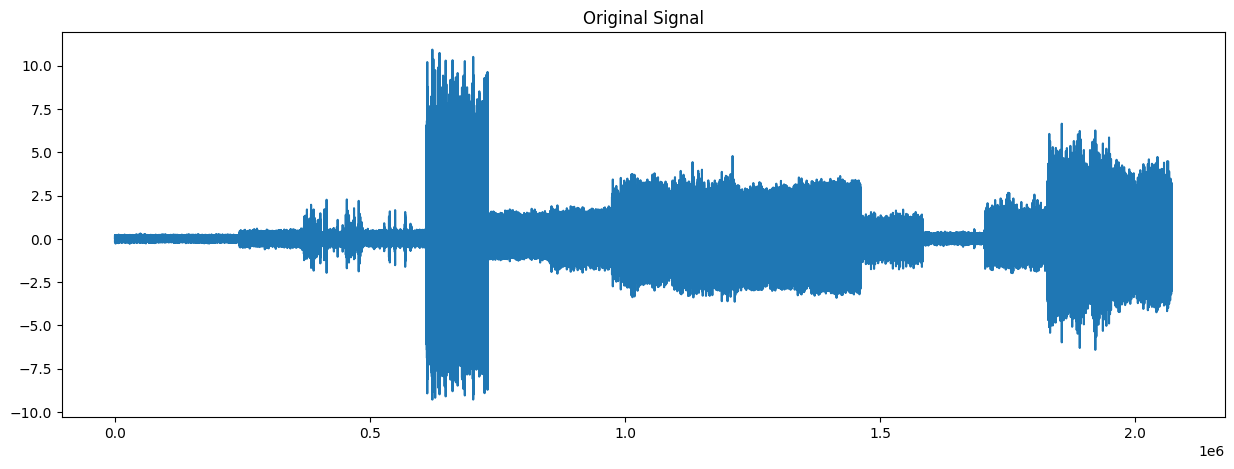

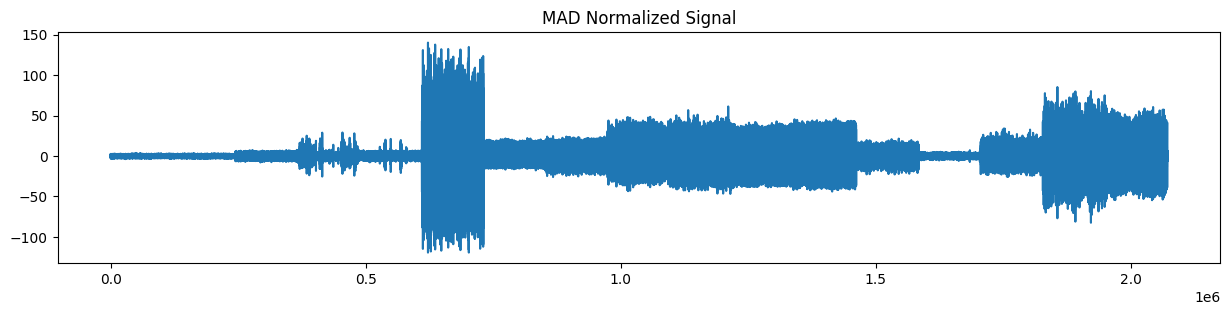

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(df["DE_data"])
plt.title("Original Signal")
plt.show()

plt.figure(figsize=(15,3))
plt.plot(df["signal_norm"])
plt.title("MAD Normalized Signal")
plt.show()

In [6]:
df.to_parquet("CWRU/12k data/0_hp_load/CWRU_0hp_MAD.parquet")

In [7]:
df=pd.read_parquet('CWRU/12k data/0_hp_load/CWRU_0hp_MAD.parquet')

In [8]:
df

,DE_data,fault,signal_norm
0,0.053197,Normal,0.460690
1,0.088662,Normal,0.916022
2,0.099718,Normal,1.057979
3,0.058621,Normal,0.530329
4,-0.004590,Normal,-0.281235
...,...,...,...
2071562,-0.500706,21 OR3,-6.650913
2071563,0.090964,21 OR3,0.945580
2071564,0.375225,21 OR3,4.595233
2071565,-0.218475,21 OR3,-3.027329


In [15]:
#1. Z-Score Normalization (Standardization)
mean = np.mean(signal)
std = np.std(signal)
df["z_score_norm"] = (signal - mean) / std

# 2. Min-Max Normalization
min_val = np.min(signal)
max_val = np.max(signal)
# We scale to -1 to 1 to be fair to vibration data
df["min_max_norm"] = ((signal - min_val) / (max_val - min_val))


--- Z-SCORE STATS ---
count    2.071567e+06
mean     6.146519e-18
std      1.000000e+00
min     -1.434958e+01
25%     -1.775097e-01
50%      2.075353e-03
75%      1.787495e-01
max      1.683887e+01
Name: z_score_norm, dtype: float64

--- MIN-MAX STATS ---
count    2.071567e+06
mean     4.600927e-01
std      3.206316e-02
min      0.000000e+00
25%      4.544012e-01
50%      4.601593e-01
75%      4.658240e-01
max      1.000000e+00
Name: min_max_norm, dtype: float64


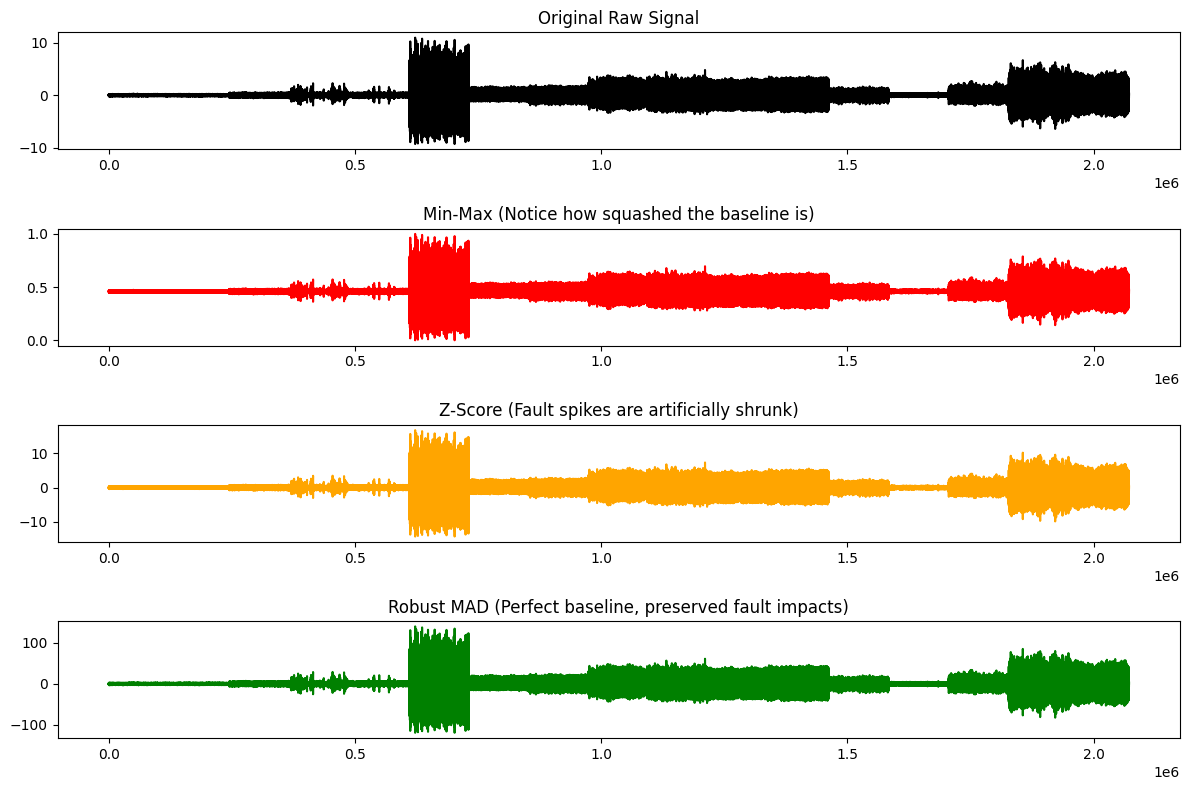

In [20]:
# 3. Print the Statistical Proof
# ==========================================
print("\n--- Z-SCORE STATS ---")
print(df["z_score_norm"].describe())

print("\n--- MIN-MAX STATS ---")
print(df["min_max_norm"].describe())

# ==========================================
# 4. Visual Proof for your Thesis
# ==========================================
# Plotting 2000 points to see the squashing effect
plt.figure(figsize=(12, 8))

plt.subplot(4, 1, 1)
plt.plot(df["DE_data"], color='black')
plt.title("Original Raw Signal")

plt.subplot(4, 1, 2)
plt.plot(df["min_max_norm"], color='red')
plt.title("Min-Max (Notice how squashed the baseline is)")

plt.subplot(4, 1, 3)
plt.plot(df["z_score_norm"], color='orange')
plt.title("Z-Score (Fault spikes are artificially shrunk)")

plt.subplot(4, 1, 4)
plt.plot(df["signal_norm"], color='green') # Your MAD data
plt.title("Robust MAD (Perfect baseline, preserved fault impacts)")

plt.tight_layout()
plt.show()

In [9]:
print("SHAPE")
print(df.shape)

print("\nCOLUMNS")
print(df.columns.tolist())

print("\nUNIQUE FAULT CLASSES")
print(df['fault'].unique())

print("\nCLASS COUNTS")
print(df['fault'].value_counts())

print("\nTOTAL CLASSES")
print(df['fault'].nunique())

SHAPE
(2071567, 3)

COLUMNS
['DE_data', 'fault', 'signal_norm']

UNIQUE FAULT CLASSES
<ArrowStringArray>
['Normal',   '07 B',   '14 B',   '21 B',   '28 B',  '07 IR',  '14 IR',
  '21 IR',  '28 IR', '07 OR1', '07 OR2', '07 OR3',  '14 OR', '21 OR1',
 '21 OR2', '21 OR3']
Length: 16, dtype: str

CLASS COUNTS
fault
Normal    243938
07 B      122571
21 OR2    122426
07 OR1    122281
07 OR3    122281
21 IR     122136
21 B      121991
07 OR2    121991
14 B      121846
14 IR     121846
14 OR     121846
21 OR3    121846
21 OR1    121701
07 IR     121265
28 B      120801
28 IR     120801
Name: count, dtype: int64

TOTAL CLASSES
16
